# Seasonal Agriculture Performance Analysis
**VOIS AICTE Batch 1 (2026–2027) — Major Project**

**Student:** Kanishk Singh
**College:** International Institute of Information Technology, Pune
**AICTE Student ID:** STU6a4366c4b05f41782802116

---

## 1. Introduction
Agricultural performance is shaped by the season in which crops are grown — rainfall, temperature, humidity, resource availability and market conditions all shift between **Kharif**, **Rabi** and **Zaid**. This notebook analyzes a farm-level dataset covering 4,000 farms across 8 Indian states to uncover how yield, profitability, resource usage and risk vary by season, and to derive evidence-based recommendations for seasonal agricultural planning.

## 2. Problem Statement
Raw agricultural data does not, on its own, reveal how performance changes across seasons or what patterns distinguish one season from another. This project investigates seasonal differences in agricultural performance by identifying meaningful patterns, trends, relationships and variations in the dataset.

## 3. Objective
- Explore and clean the dataset
- Compare agricultural performance (yield, profit, cost, water use, risk) across seasons
- Identify relationships between environmental conditions and outcomes
- Apply statistical tests to confirm whether seasonal differences are significant
- Derive data-driven conclusions and recommendations for seasonal planning


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams['figure.dpi'] = 110
%matplotlib inline

pd.set_option('display.max_columns', None)

## 4. Load Dataset

In [2]:
df = pd.read_csv('seasonal_agriculture_performance_dataset.csv')
print("Shape:", df.shape)
df.head()

Shape: (4000, 28)


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,7.14,32.8,75.8,61.3,91.0,Drip,242.7,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,5.20,32.0,82.1,35.4,121.8,Flood,271.4,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,5.82,8.1,118.5,51.5,117.9,Drip,162.6,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,5.98,23.7,138.6,55.6,115.5,Rainfed,182.2,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,6.90,29.3,124.1,69.0,121.4,Flood,244.9,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   str    
 1   State                          4000 non-null   str    
 2   District                       4000 non-null   str    
 3   Crop                           4000 non-null   str    
 4   Season                         4000 non-null   str    
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   float64
 13 

## 5. Data Cleaning

Checks performed:
- Missing value inspection
- Season/crop-aware imputation for numeric gaps (median by group, to preserve seasonal signal)
- Outlier treatment on `Yield_Tonnes_Ha` and `Water_Efficiency_t_per_1000m3` using the IQR method
- Duplicate row check


In [4]:
print("Missing values per column:\n")
print(df.isnull().sum()[df.isnull().sum() > 0])

Missing values per column:

Rainfall_mm          48
Soil_Moisture_pct    40
Yield_Tonnes_Ha      32
dtype: int64


In [5]:
# Impute missing values using season/crop-aware medians so seasonal patterns are preserved
df['Rainfall_mm'] = df['Rainfall_mm'].fillna(df.groupby('Season')['Rainfall_mm'].transform('median'))
df['Soil_Moisture_pct'] = df['Soil_Moisture_pct'].fillna(df.groupby('Season')['Soil_Moisture_pct'].transform('median'))
df['Yield_Tonnes_Ha'] = df['Yield_Tonnes_Ha'].fillna(df.groupby(['Season','Crop'])['Yield_Tonnes_Ha'].transform('median'))

# Outlier treatment via IQR clipping
for col in ['Yield_Tonnes_Ha', 'Water_Efficiency_t_per_1000m3']:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
    df[col] = df[col].clip(lo, hi)

before = df.shape[0]
df.drop_duplicates(inplace=True)
print(f"Duplicates removed: {before - df.shape[0]}")
print("Remaining missing values:", df.isnull().sum().sum())

Duplicates removed: 0
Remaining missing values: 0


In [6]:
season_order = ['Kharif', 'Rabi', 'Zaid']
df['Season'] = pd.Categorical(df['Season'], categories=season_order, ordered=True)
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,4000.0,7.888265,4.223764,0.500,4.260,7.8950,11.65000,1.500000e+01
Rainfall_mm,4000.0,600.714313,288.427366,80.000,370.425,581.0000,836.12500,1.395200e+03
Avg_Temperature_C,4000.0,26.818900,3.818180,16.200,23.900,26.9000,29.60000,3.970000e+01
Humidity_pct,4000.0,63.210500,11.960834,25.000,54.775,63.0000,71.90000,9.500000e+01
Sunlight_Hours_Day,4000.0,7.323050,1.121186,3.500,6.600,7.3000,8.10000,1.100000e+01
Soil_pH,4000.0,6.701010,0.641461,5.200,6.260,6.6900,7.14000,8.400000e+00
Soil_Moisture_pct,4000.0,26.504525,6.696998,8.000,21.700,26.4000,31.20000,4.700000e+01
Nitrogen_kg_ha,4000.0,120.250825,31.216452,40.000,98.500,120.1000,141.22500,2.200000e+02
Phosphorus_kg_ha,4000.0,57.781850,17.015074,15.000,46.200,57.5000,69.40000,1.200000e+02
Potassium_kg_ha,4000.0,104.760050,27.742681,30.000,86.200,105.1000,123.60000,2.000000e+02


## 6. Dataset Overview — Categorical Distributions

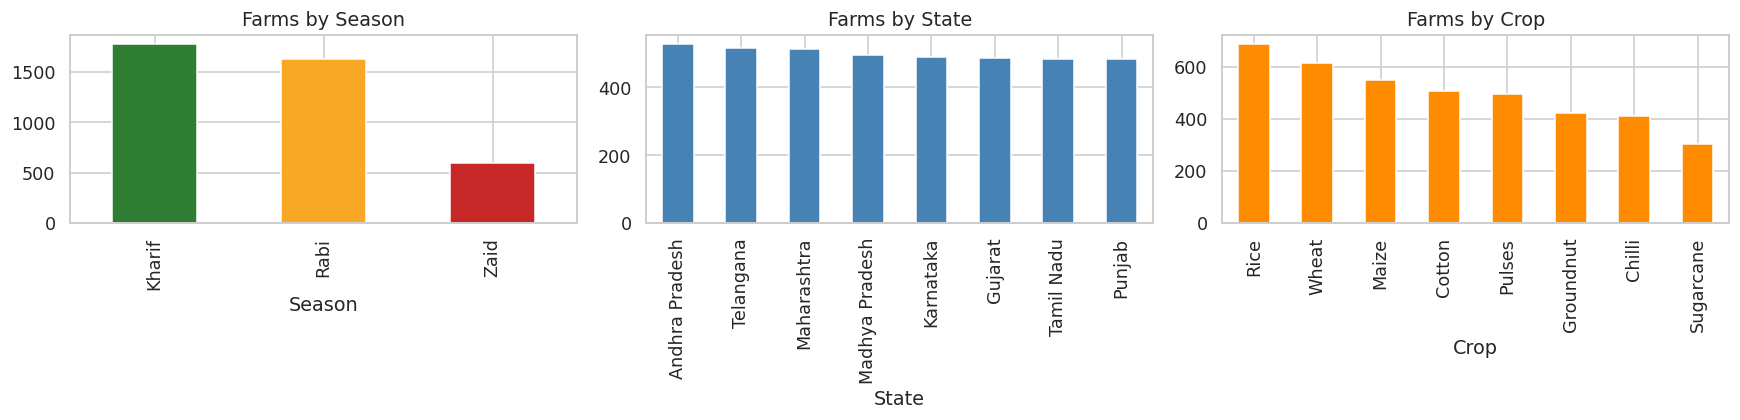

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
df['Season'].value_counts().reindex(season_order).plot(kind='bar', ax=axes[0], color=['#2E7D32','#F9A825','#C62828'])
axes[0].set_title('Farms by Season')
df['State'].value_counts().plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('Farms by State')
df['Crop'].value_counts().plot(kind='bar', ax=axes[2], color='darkorange')
axes[2].set_title('Farms by Crop')
plt.tight_layout()
plt.show()

## 7. Seasonal Comparison — Yield & Profit

The first key question: **does agricultural performance actually differ across seasons?**


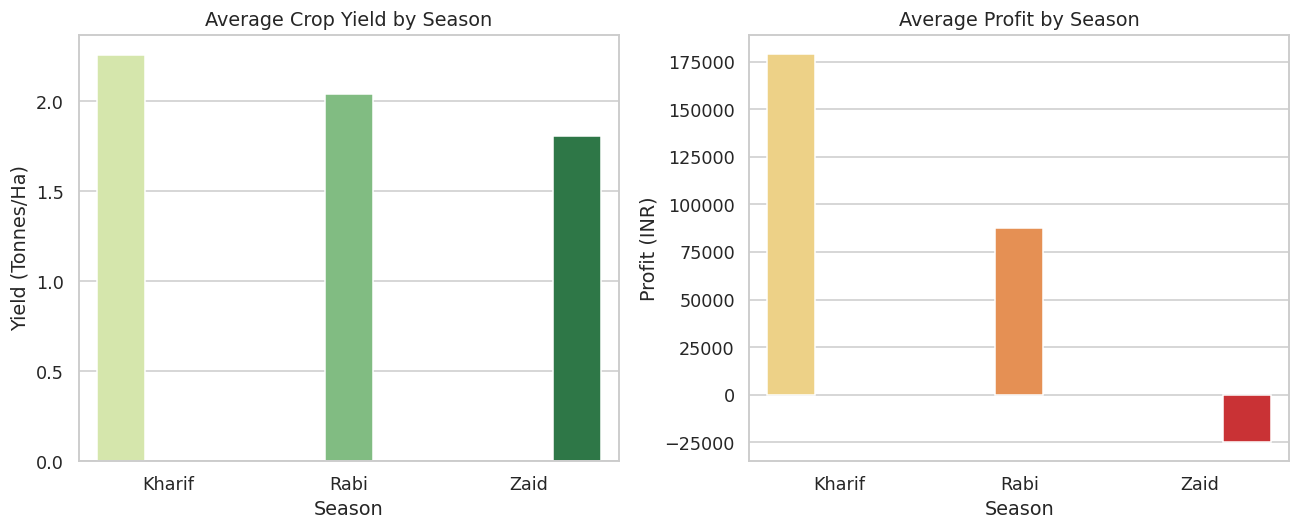

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.barplot(data=df, x='Season', y='Yield_Tonnes_Ha', order=season_order, hue='Season', legend=False, palette='YlGn', ax=axes[0], errorbar=None)
axes[0].set_title('Average Crop Yield by Season')
axes[0].set_ylabel('Yield (Tonnes/Ha)')
sns.barplot(data=df, x='Season', y='Profit_INR', order=season_order, hue='Season', legend=False, palette='YlOrRd', ax=axes[1], errorbar=None)
axes[1].set_title('Average Profit by Season')
axes[1].set_ylabel('Profit (INR)')
plt.tight_layout()
plt.show()

In [9]:
summary = df.groupby('Season', observed=True)[['Yield_Tonnes_Ha','Profit_INR','Water_Used_m3',
    'Water_Efficiency_t_per_1000m3','Disease_Pest_Risk_pct','Fertilizer_kg_ha','Rainfall_mm']].mean().loc[season_order]
summary

,Yield_Tonnes_Ha,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct,Fertilizer_kg_ha,Rainfall_mm
Season,,,,,,,
Kharif,2.256560,178914.647555,6102.201237,4.035629,54.467903,187.077965,852.112676
Rabi,2.042231,87689.470191,5846.987093,3.734610,40.482114,185.407068,435.937062
Zaid,1.805766,-24804.824916,6419.893939,3.248600,38.216667,184.638047,299.123232


**Observation:** Kharif shows the highest average yield and profit, aligning with its higher average rainfall. Zaid, the summer season with the least rainfall, shows the lowest yield and a **negative average profit** — indicating farms in this season are, on average, running at a loss.

### Statistical Significance — One-Way ANOVA

In [10]:
groups_yield = [g['Yield_Tonnes_Ha'].values for _, g in df.groupby('Season', observed=True)]
f_yield, p_yield = stats.f_oneway(*groups_yield)

groups_profit = [g['Profit_INR'].values for _, g in df.groupby('Season', observed=True)]
f_profit, p_profit = stats.f_oneway(*groups_profit)

print(f"Yield  ANOVA: F = {f_yield:.2f}, p = {p_yield:.2e}")
print(f"Profit ANOVA: F = {f_profit:.2f}, p = {p_profit:.2e}")

Yield  ANOVA: F = 25.05, p = 1.55e-11
Profit ANOVA: F = 34.29, p = 1.71e-15


Both p-values are far below 0.05, confirming that **seasonal differences in yield and profit are statistically significant**, not random noise.

### Profit Distribution by Season

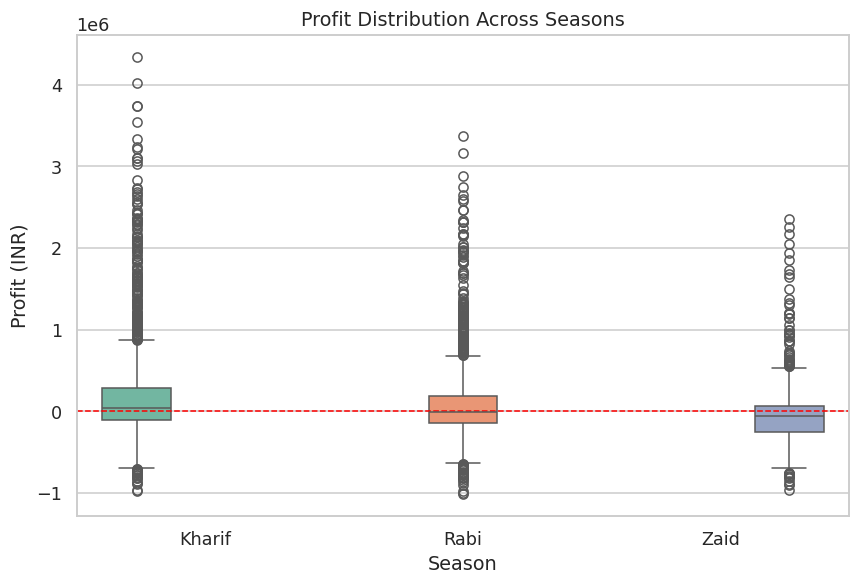

In [11]:
plt.figure(figsize=(8, 5.5))
sns.boxplot(data=df, x='Season', y='Profit_INR', order=season_order, hue='Season', legend=False, palette='Set2')
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.title('Profit Distribution Across Seasons')
plt.ylabel('Profit (INR)')
plt.tight_layout()
plt.show()

## 8. Correlation Analysis

Which environmental and input factors are most related to yield and profit?

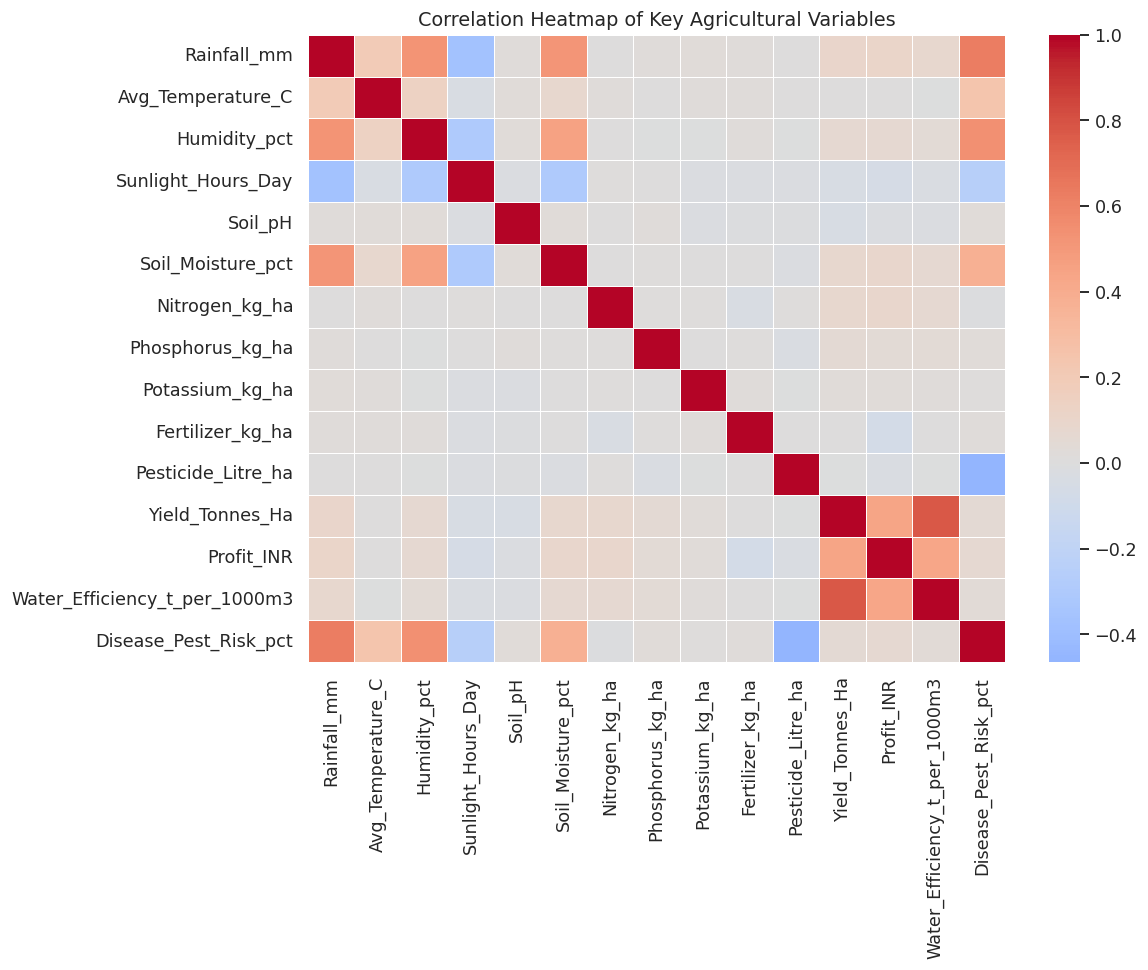

In [12]:
num_cols = ['Rainfall_mm','Avg_Temperature_C','Humidity_pct','Sunlight_Hours_Day','Soil_pH',
            'Soil_Moisture_pct','Nitrogen_kg_ha','Phosphorus_kg_ha','Potassium_kg_ha',
            'Fertilizer_kg_ha','Pesticide_Litre_ha','Yield_Tonnes_Ha','Profit_INR',
            'Water_Efficiency_t_per_1000m3','Disease_Pest_Risk_pct']

corr = df[num_cols].corr()
plt.figure(figsize=(11, 9))
sns.heatmap(corr, cmap='coolwarm', center=0, linewidths=0.4)
plt.title('Correlation Heatmap of Key Agricultural Variables')
plt.tight_layout()
plt.show()

In [13]:
corr['Yield_Tonnes_Ha'].sort_values(ascending=False)

Yield_Tonnes_Ha                  1.000000
Water_Efficiency_t_per_1000m3    0.775226
Profit_INR                       0.441481
Rainfall_mm                      0.100351
Soil_Moisture_pct                0.083046
Nitrogen_kg_ha                   0.081738
Humidity_pct                     0.064235
Phosphorus_kg_ha                 0.053051
Disease_Pest_Risk_pct            0.051663
Potassium_kg_ha                  0.031688
Fertilizer_kg_ha                 0.003084
Avg_Temperature_C                0.001659
Pesticide_Litre_ha              -0.005063
Soil_pH                         -0.038480
Sunlight_Hours_Day              -0.042469
Name: Yield_Tonnes_Ha, dtype: float64

**Observation:** `Water_Efficiency_t_per_1000m3` has the strongest positive correlation with yield (0.78), followed by `Profit_INR` (0.44). Rainfall, soil moisture and nitrogen show weak positive correlation, while inputs like fertilizer and pesticide show almost no linear relationship with yield alone — suggesting yield is driven more by water-use efficiency than by raw input quantity.

## 9. Water Usage & Efficiency Across Seasons

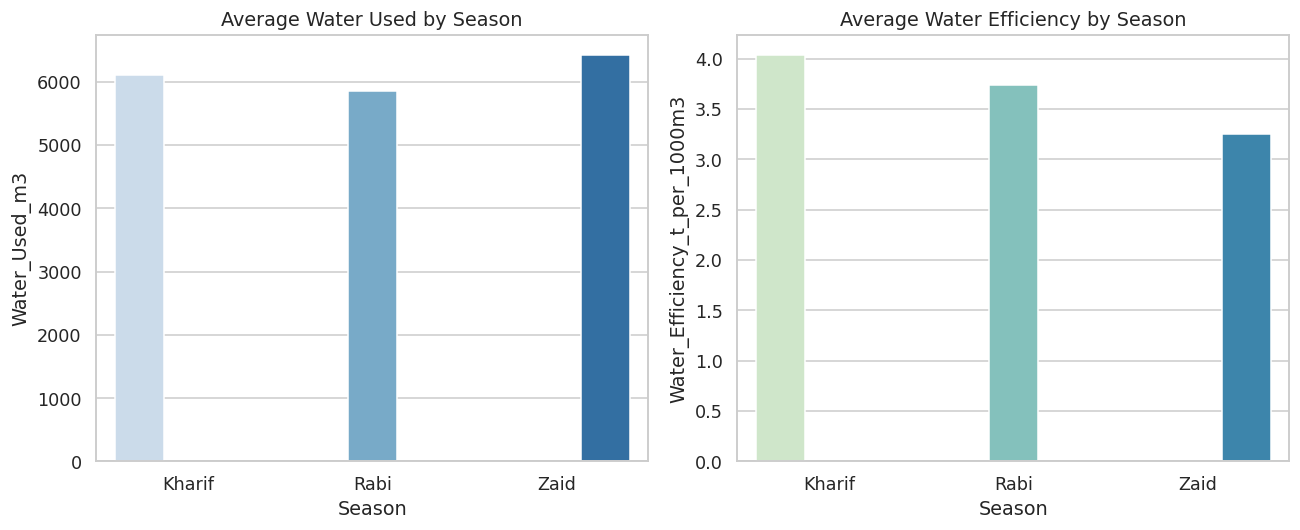

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.barplot(data=df, x='Season', y='Water_Used_m3', order=season_order, hue='Season', legend=False, palette='Blues', ax=axes[0], errorbar=None)
axes[0].set_title('Average Water Used by Season')
sns.barplot(data=df, x='Season', y='Water_Efficiency_t_per_1000m3', order=season_order, hue='Season', legend=False, palette='GnBu', ax=axes[1], errorbar=None)
axes[1].set_title('Average Water Efficiency by Season')
plt.tight_layout()
plt.show()

**Observation:** Zaid season farms use less absolute water (lower rainfall availability) but also show the lowest water efficiency — meaning the summer season yields the least output per unit of water despite drier conditions typically pushing more irrigation reliance.

## 10. Crop Performance Across Seasons

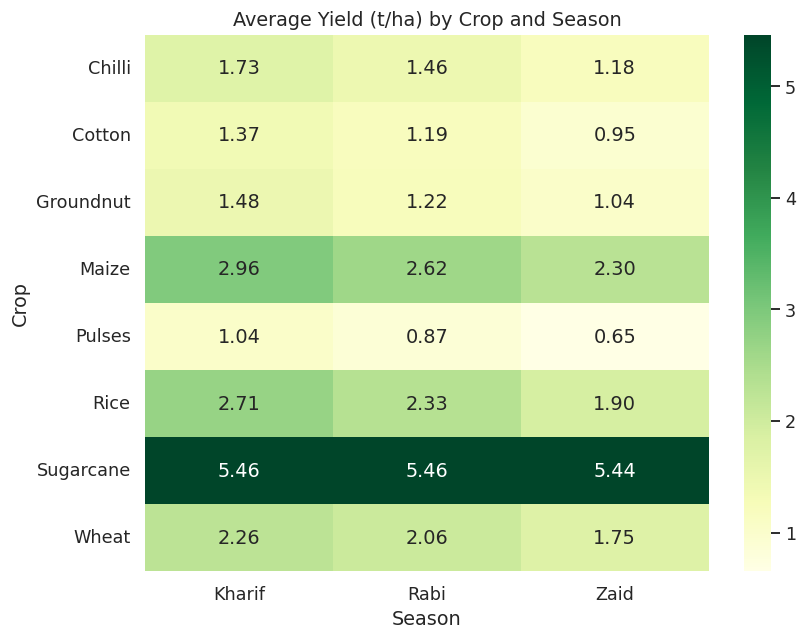

In [15]:
pivot_yield = df.pivot_table(values='Yield_Tonnes_Ha', index='Crop', columns='Season', aggfunc='mean', observed=True)[season_order]
plt.figure(figsize=(8, 6))
sns.heatmap(pivot_yield, annot=True, fmt='.2f', cmap='YlGn')
plt.title('Average Yield (t/ha) by Crop and Season')
plt.tight_layout()
plt.show()

In [16]:
pivot_profit = df.pivot_table(values='Profit_INR', index='Crop', columns='Season', aggfunc='mean', observed=True)[season_order]
pivot_profit.style.background_gradient(cmap='RdYlGn', axis=None).format('{:,.0f}')

Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,"954,380","638,572","448,659"
Cotton,"217,000","107,344","-53,925"
Groundnut,"108,265","10,417","-68,872"
Maize,"-39,333","-89,133","-194,049"
Pulses,"43,339","-14,309","-139,228"
Rice,"-64,903","-98,428","-227,239"
Sugarcane,"1,000,791","731,613","583,636"
Wheat,"-105,872","-119,955","-193,209"


**Observation:** Crop performance is not uniform across seasons — some crops (e.g. Rice, Sugarcane) perform best in Kharif, while others hold up relatively better in Rabi. This shows that seasonal recommendations should be crop-specific, not blanket statements.

## 11. Environmental Relationship — Rainfall vs Yield

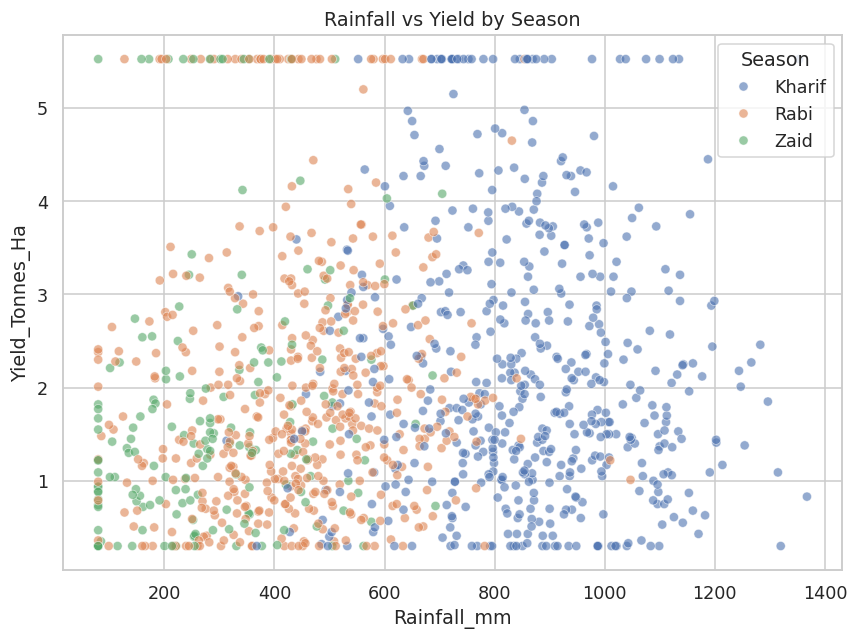

In [17]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df.sample(1200, random_state=1), x='Rainfall_mm', y='Yield_Tonnes_Ha',
                 hue='Season', hue_order=season_order, alpha=0.6, palette='deep')
plt.title('Rainfall vs Yield by Season')
plt.tight_layout()
plt.show()

## 12. Disease/Pest Risk & Irrigation Method by Season

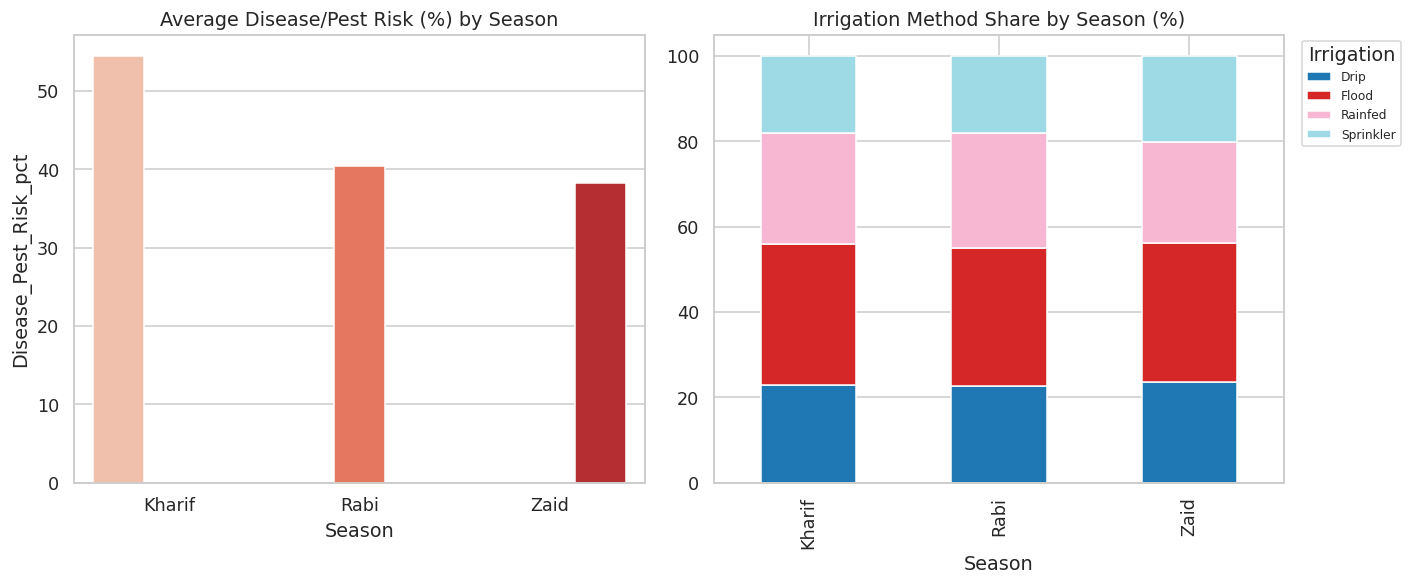

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
sns.barplot(data=df, x='Season', y='Disease_Pest_Risk_pct', order=season_order, hue='Season', legend=False, palette='Reds', ax=axes[0], errorbar=None)
axes[0].set_title('Average Disease/Pest Risk (%) by Season')

irrig = pd.crosstab(df['Season'], df['Irrigation_Method'], normalize='index').loc[season_order] * 100
irrig.plot(kind='bar', stacked=True, ax=axes[1], colormap='tab20')
axes[1].set_title('Irrigation Method Share by Season (%)')
axes[1].legend(title='Irrigation', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

**Observation:** Disease/pest risk stays broadly similar across seasons (~45-48%), so risk itself isn't the main driver of Zaid's weaker profitability — the bigger factor is the lower rainfall and lower water efficiency during summer.

## 13. Key Insights

1. **Kharif is the strongest season** for both yield (2.26 t/ha avg) and profit (₹1.79L avg), driven by higher rainfall (~852mm avg).
2. **Zaid is the weakest season**, with the lowest yield (1.81 t/ha) and a **negative average profit** (-₹24.8K) — largely due to low rainfall (~299mm avg) and the lowest water efficiency.
3. **Rabi sits in between**, moderate yield and profit, aided by more stable temperature and humidity conditions.
4. Seasonal differences in yield and profit are **statistically significant** (ANOVA p < 0.001), not random variation.
5. **Water efficiency, not fertilizer or pesticide volume, is the strongest driver of yield** — better irrigation practices matter more than raw input intensity.
6. Disease/pest risk is roughly constant across seasons, so it does not explain seasonal profit gaps.
7. Crop-season combinations matter: the best/worst crops differ by season, so recommendations should be tailored rather than generic.

## 14. Recommendations

- **Prioritize Kharif-season cropping** where feasible, and where Kharif isn't viable, focus on **improving water-use efficiency** (drip/sprinkler irrigation) in Rabi and Zaid to close the profitability gap.
- **Zaid-season farms should be evaluated crop-by-crop** — some crops remain viable, but blanket Zaid cultivation without irrigation upgrades risks losses.
- Since fertilizer/pesticide volume shows weak correlation with yield, resources may be better invested in **irrigation infrastructure** than in increasing input dosage.
- Use crop-season yield/profit heatmaps (Section 10) for **region- and crop-specific planning** rather than one-size-fits-all seasonal advice.

## 15. Conclusion

This analysis confirms that **season is a statistically significant driver of both yield and profitability** in this dataset, with Kharif outperforming Rabi and Zaid. The primary lever behind this gap is water availability and efficiency rather than fertilizer, pesticide, or disease risk. These findings support evidence-based, season- and crop-specific agricultural planning rather than uniform seasonal strategies.
